In [65]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [66]:
df = pd.read_csv("../DATA/Anthocyanin_231125-311225.csv")

df.sort_values(by="DATE", inplace=True)
df.head(1)

,Lettuce color,catalog id,Leaf sample weight (mg),Sample disc weight (g),Anthocyanins OD-530 nm,Chlorophyll OD-657 nm,Chlorophyll interference,Anthocyanin,DATE,Illumination
73,GREEN,C9,0.33,0.03,0.1504,0.08,0.02,0.13,05/12/2025,Control-Sun


In [67]:
df.columns

Index(['Lettuce color', 'catalog id', 'Leaf sample weight (mg)',
       'Sample disc weight (g)', 'Anthocyanins OD-530 nm',
       'Chlorophyll OD-657 nm', 'Chlorophyll interference', 'Anthocyanin',
       'DATE', 'Illumination'],
      dtype='str')

In [68]:
target='Chlorophyll OD-657 nm'
df_red=df[df['Lettuce color'] == 'RED']
df_green=df[df['Lettuce color'] == 'GREEN']

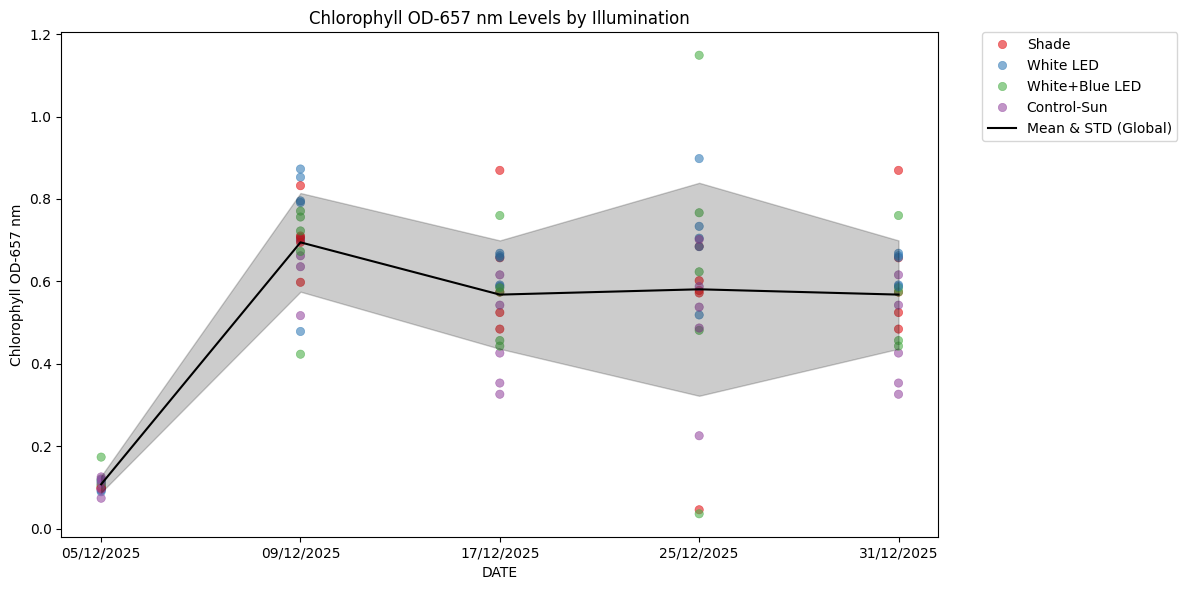

In [69]:


# 1. Create the figure
plt.figure(figsize=(12, 6))

# 2. Draw the Scatter Plot with Seaborn
# 'hue' handles the colors and creates the legend automatically
sns.scatterplot(
    data=df_red, 
    x='DATE', 
    y=target, 
    hue='Illumination', 
    palette='Set1', 
    alpha=0.6,
    edgecolor=None
)

# 3. Draw the Mean + STD line on top
sns.lineplot(
    data=df_red, 
    x='DATE', 
    y=target, 
    color='black', 
    errorbar='sd', 
    label='Mean & STD (Global)'
)

# 4. Move the legend so it doesn't cover the data
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.title(f'{target} Levels by Illumination')
plt.tight_layout() # Prevents the legend from being cut off
plt.show()

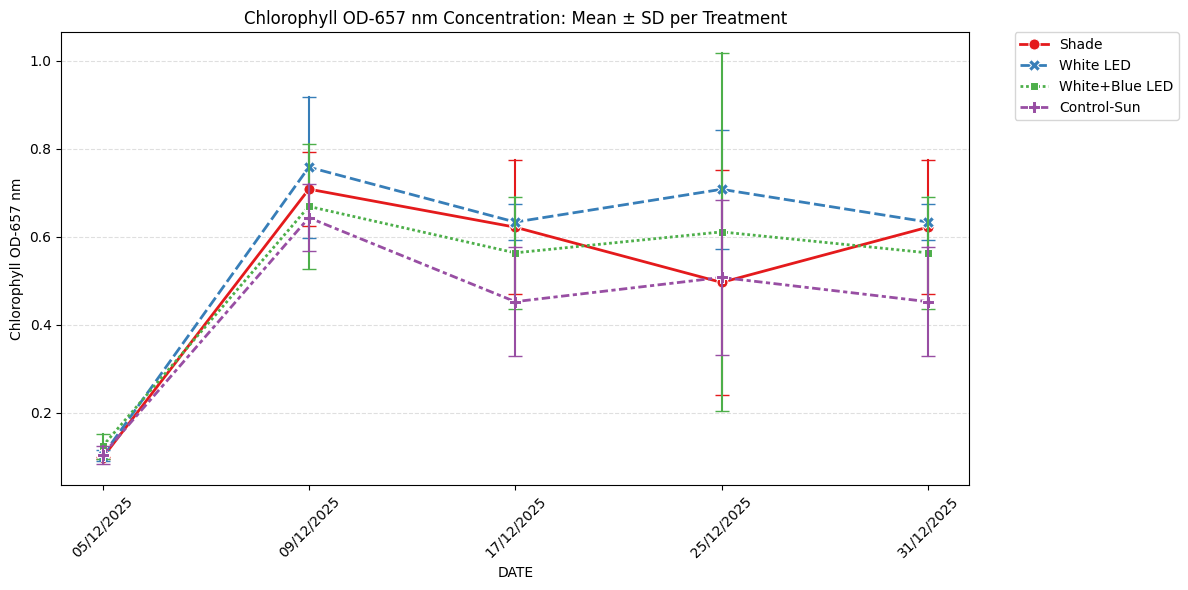

In [70]:


plt.figure(figsize=(12, 6))

# Use err_kws to pass capsize to the underlying errorbar function
sns.lineplot(
    data=df_red, 
    x='DATE', 
    y=target, 
    hue='Illumination', 
    style='Illumination',
    markers=True,         
    errorbar='sd',        
    err_style='bars',     
    err_kws={'capsize': 5},  # This is the fix!
    palette='Set1',
    linewidth=2,
    markersize=8
)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.title(f'{target} Concentration: Mean ± SD per Treatment')
plt.ylabel(f'{target}')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

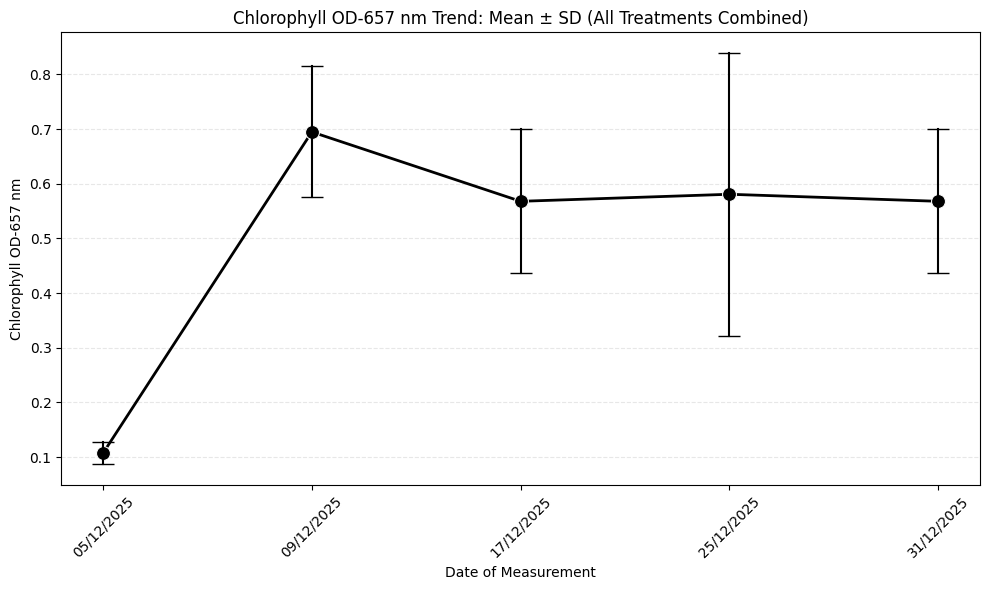

In [71]:


# 1. Create the figure
plt.figure(figsize=(10, 6))

# 2. Draw the Global Error Bar Plot
# By removing 'hue', we force Seaborn to aggregate ALL treatments together
sns.lineplot(
    data=df_red, 
    x='DATE', 
    y=target, 
    marker='o',           # Adds a single dot for the global mean
    errorbar='sd',        # Calculates the SD of all samples on that date
    err_style='bars',     # Shows the "I" bars
    err_kws={'capsize': 8}, 
    color='black',        # A neutral color for global data
    linewidth=2,
    markersize=10
)

# 3. Formatting
plt.title(f'{target} Trend: Mean ± SD (All Treatments Combined)')
plt.ylabel(f'{target}')
plt.xlabel('Date of Measurement')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [72]:
# 1. Group by DATE
# 2. Pick the column target
# 3. Aggregate by 'mean' and 'std'
stats_df = df_red.groupby('DATE')[target].agg(['mean', 'std']).reset_index()

# Display the result
print(stats_df)

         DATE      mean       std
0  05/12/2025  0.107295  0.019923
1  09/12/2025  0.694635  0.119752
2  17/12/2025  0.567790  0.131547
3  25/12/2025  0.580680  0.258495
4  31/12/2025  0.567790  0.131547


In [73]:
# Group by two columns instead of one
detailed_stats = df_red.groupby(['DATE', 'Illumination'])[target].agg(['mean', 'std']).reset_index()

# This gives you a row for every unique Date-Illumination combination
# Sort by Illumination alphabetically
detailed_stats = detailed_stats.sort_values(by=['Illumination','DATE' ])

# Display the sorted result
print(detailed_stats)

          DATE    Illumination     mean       std
0   05/12/2025     Control-Sun  0.10454  0.020837
4   09/12/2025     Control-Sun  0.64336  0.076051
8   17/12/2025     Control-Sun  0.45256  0.123790
12  25/12/2025     Control-Sun  0.50764  0.176814
16  31/12/2025     Control-Sun  0.45256  0.123790
1   05/12/2025           Shade  0.09804  0.002446
5   09/12/2025           Shade  0.70820  0.083330
9   17/12/2025           Shade  0.62172  0.152704
13  25/12/2025           Shade  0.49628  0.256004
17  31/12/2025           Shade  0.62172  0.152704
2   05/12/2025       White LED  0.10244  0.012330
6   09/12/2025       White LED  0.75806  0.160356
10  17/12/2025       White LED  0.63342  0.040362
14  25/12/2025       White LED  0.70778  0.135347
18  31/12/2025       White LED  0.63342  0.040362
3   05/12/2025  White+Blue LED  0.12416  0.028137
7   09/12/2025  White+Blue LED  0.66892  0.142495
11  17/12/2025  White+Blue LED  0.56346  0.127612
15  25/12/2025  White+Blue LED  0.61102  0.406640


c:\myProjects\phenomobile\.venv\Lib\site-packages\pandas\plotting\_matplotlib\core.py:1388: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(


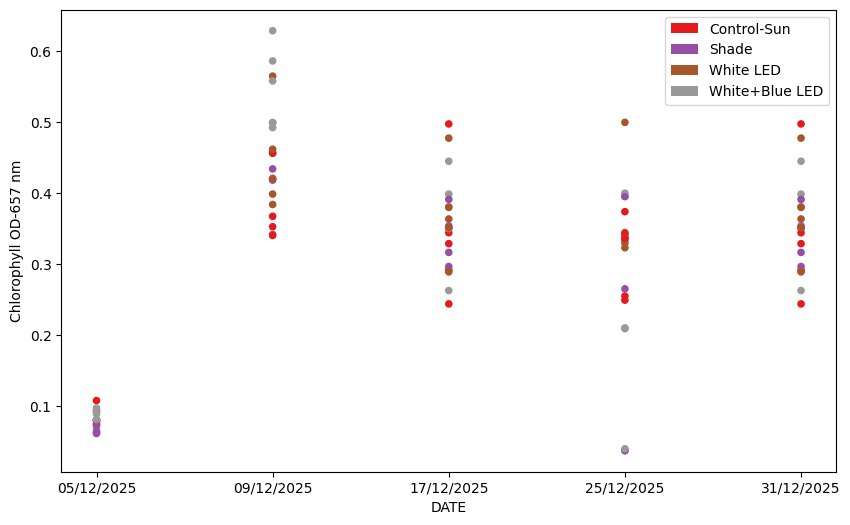

In [74]:
df_green=df[df['Lettuce color'] == 'GREEN']


df_green.plot.scatter(x='DATE', y=target, 
        c='Illumination', 
        colormap='Set1',figsize=(10, 6) ,
        sharex=False)          

plt.show()